# 2. Self-supervised features for cancer classification (DMR-IR)

A ResNet-50 pretrained with **VICReg** on unlabeled thermograms is frozen, and a classifier is trained on its features with a small number of labels.

**Protocol** (`scripts/classification/benchmark.py`): 1,000 DMR-IR frames from 44 patients; 5-fold cross-validation grouped by patient, so every patient's frames are tested by a model that never saw that patient; for each label budget, 5 class-balanced random subsets of the training fold. Classifiers use fixed hyperparameters and no validation labels, so a budget of *n* images means exactly *n* labels. All encoders receive identical inputs. ROC AUC is reported as mean ± std across the 5 folds.

**Encoders compared** (all frozen ResNet-50, pooled `layer3` + `layer4` features):

- *VICReg (ours)*: self-supervised pretraining on unlabeled clinical thermograms.
- *VICReg + adaptation*: the same backbone, trained further with the VICReg objective on unlabeled breast-only DMR-IR images of each fold's training patients (`scripts/ssl/vicreg_adapt.py`); the fold's test patients are never seen.
- *ImageNet*: supervised pretraining on 1.28M natural images, the standard transfer-learning baseline.
- *Random init*: no pretraining, the lower bound.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS = Path("../results")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#8a8a85",
        "axes.labelcolor": "#2b2b29",
        "axes.titleweight": "bold",
        "xtick.color": "#5c5c58",
        "ytick.color": "#5c5c58",
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": "#e4e4e0",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
    }
)
# Categorical palette in fixed order (validated for colour-vision deficiencies).
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

In [2]:
bench = pd.read_csv(RESULTS / "classification_benchmark.csv")
bench["n_labeled"] = bench["n_labeled"].astype(str)
ORDER = ["16", "32", "64", "128", "256", "all"]
ENCODERS = ["VICReg + adaptation", "ImageNet", "VICReg (ours)", "Random init"]


def auc_table(df, by):
    per_fold = df.groupby([*by, "n_labeled", "fold"]).auc.mean().reset_index()
    stats = per_fold.groupby([*by, "n_labeled"]).auc.agg(["mean", "std"])
    cell = stats["mean"].map("{:.3f}".format) + " ± " + stats["std"].map("{:.3f}".format)
    return cell.unstack("n_labeled")[ORDER]

## 2.1 Segmentation-guided input

The same VICReg backbone, fed either the whole thermogram or only the breasts (background outside the R2AttU-Net mask set to zero).

In [3]:
vic = bench[(bench.encoder == "VICReg (ours)") & (bench["head"] == "logreg")]
auc_table(vic, ["input"])

n_labeled,16,32,64,128,256,all
input,,,,,,
full,0.636 ± 0.067,0.667 ± 0.060,0.721 ± 0.155,0.791 ± 0.136,0.836 ± 0.128,0.886 ± 0.110
masked,0.778 ± 0.089,0.833 ± 0.105,0.866 ± 0.067,0.873 ± 0.088,0.883 ± 0.098,0.912 ± 0.079


## 2.2 VICReg against ImageNet and random initialisation (breast-only input)

In [4]:
masked = bench[(bench.input == "masked") & (bench["head"] == "logreg")]
auc_table(masked, ["encoder"])

n_labeled,16,32,64,128,256,all
encoder,,,,,,
ImageNet,0.880 ± 0.074,0.899 ± 0.084,0.921 ± 0.058,0.937 ± 0.057,0.943 ± 0.059,0.950 ± 0.058
Random init,0.756 ± 0.072,0.794 ± 0.101,0.810 ± 0.091,0.801 ± 0.098,0.801 ± 0.078,0.775 ± 0.091
VICReg (ours),0.778 ± 0.089,0.833 ± 0.105,0.866 ± 0.067,0.873 ± 0.088,0.883 ± 0.098,0.912 ± 0.079
VICReg + adaptation,0.895 ± 0.089,0.937 ± 0.066,0.938 ± 0.072,0.945 ± 0.061,0.940 ± 0.064,0.925 ± 0.078


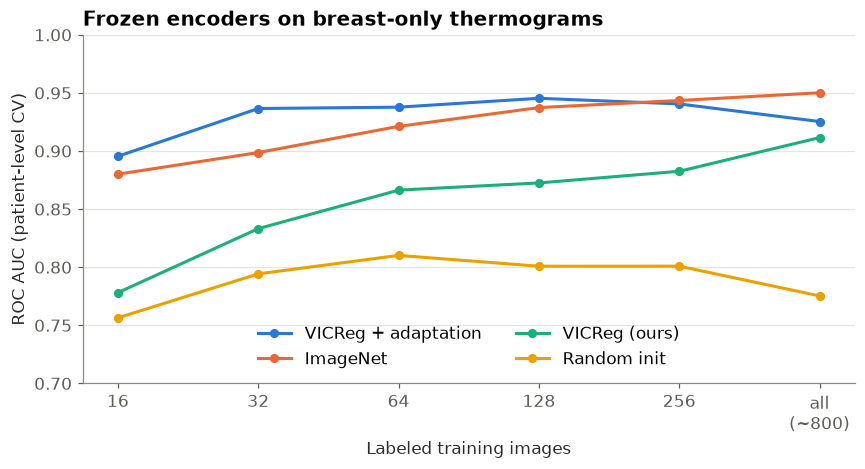

In [5]:
per_fold = masked.groupby(["encoder", "n_labeled", "fold"]).auc.mean().reset_index()
stats = per_fold.groupby(["encoder", "n_labeled"]).auc.agg(["mean", "std"])
x = np.arange(len(ORDER))
fig, ax = plt.subplots(figsize=(8, 4.4))
for color, encoder in zip(COLORS, ENCODERS):
    s = stats.loc[encoder].loc[ORDER]
    ax.plot(x, s["mean"], color=color, linewidth=2, marker="o", markersize=5, label=encoder)
ax.set_xticks(x, [o if o != "all" else "all\n(~800)" for o in ORDER])
ax.set_xlabel("Labeled training images")
ax.set_ylabel("ROC AUC (patient-level CV)")
ax.set_ylim(0.7, 1.0)
ax.set_title("Frozen encoders on breast-only thermograms", loc="left")
ax.legend(loc="lower center", ncols=2)
fig.tight_layout()
fig.savefig(FIGURES / "classification_label_efficiency.png", dpi=200)

## 2.3 Classification head

In [6]:
vic_masked = bench[(bench.encoder == "VICReg (ours)") & (bench.input == "masked")]
auc_table(vic_masked, ["head"])

n_labeled,16,32,64,128,256,all
head,,,,,,
logreg,0.778 ± 0.089,0.833 ± 0.105,0.866 ± 0.067,0.873 ± 0.088,0.883 ± 0.098,0.912 ± 0.079
mlp,0.736 ± 0.134,0.821 ± 0.123,0.840 ± 0.087,0.854 ± 0.118,0.858 ± 0.136,0.873 ± 0.144


## 2.4 Patient-level diagnosis

A diagnosis is made per patient. With all training labels, every frame receives an out-of-fold probability; averaging a patient's frames gives one score per patient, evaluated over all 44 patients.

In [7]:
patients = pd.read_csv(RESULTS / "classification_benchmark_patients.csv")
cols = ["auc", "sensitivity", "specificity", "balanced_accuracy"]
patients[patients["head"] == "logreg"].set_index(["encoder", "input"])[cols].round(3)

,,auc,sensitivity,specificity,balanced_accuracy
encoder,input,,,,
VICReg (ours),masked,0.936,0.810,0.913,0.861
VICReg + adaptation,masked,0.915,0.810,0.826,0.818
ImageNet,masked,0.954,0.905,0.870,0.887
Random init,masked,0.768,0.524,0.696,0.610
VICReg (ours),full,0.888,0.810,0.826,0.818


## 2.5 VICReg pretraining

Training curves of the four self-supervised runs on the unlabeled thermograms (`results/vicreg/`). The backbone used above is the `default` run.

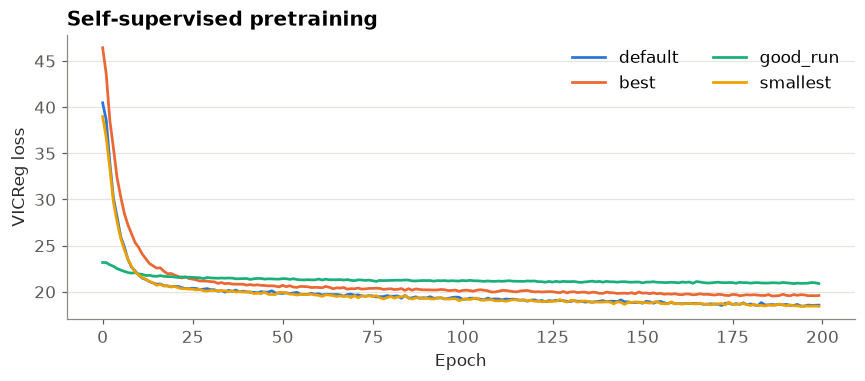

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for color, run in zip(COLORS, ["default", "best", "good_run", "smallest"]):
    log = pd.read_csv(RESULTS / "vicreg" / run / "metrics.csv")
    ax.plot(log["epoch"], log["loss"], color=color, linewidth=1.8, label=run)
ax.set_xlabel("Epoch")
ax.set_ylabel("VICReg loss")
ax.set_title("Self-supervised pretraining", loc="left")
ax.legend(loc="upper right", ncols=2)
fig.tight_layout()